# Internações Respiratórias RJ — Pipeline e Análise Exploratória (SUS 2012–2024)

Este notebook consolida as **internações por doenças respiratórias** (SUS) no **município do Rio de Janeiro** e prepara a **série diária de internações** para modelagem.
O foco é: leitura dos dados brutos anuais, filtros clínicos e geográficos coerentes com exposição ambiental e uma **análise exploratória inicial**.

> **Escopo**: 2012–2024, diagnósticos respiratórios (CID-10 selecionados), residentes do Rio (IBGE 330455) e permanência hospitalar > 0.

## Objetivos desta etapa
1. **Carregar** todos os CSVs anuais (2012–2024) diretamente do GitHub (*raw*).
2. **Padronizar** campos-chave (datas, CID-10) e **filtrar** registros de interesse.
3. **Construir** a série **diária** de internações (`data_dia` × `internacoes`).
4. **Explorar** o comportamento da série (tendência, sazonalidade, distribuição) e variáveis-chave (idade, permanência).
5. **Salvar** a série diária para uso posterior na modelagem.

## Configurações e importações
Bibliotecas usadas e parâmetros gerais.

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import acf
from scipy.signal import periodogram
from numpy.linalg import lstsq

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

## Carregamento e Unificação das Estações

Nesta etapa:

- **Origem:** `data/datasus/Ano/dados_filtrados_{ANO}.csv` (2012–2024) no branch `refs/heads/main`.
- **Concatenação:** une todos os anos com `ignore_index=True`.

In [2]:
anos = range(2012, 2025)
tpl = "https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/main/data/datasus/Ano/dados_filtrados_{ano}.csv"

dfs = []
for ano in anos:
    url = tpl.format(ano=ano)
    print(f"Lendo: {url}")
    df = pd.read_csv(url, encoding="utf-8")
    df["ano_arquivo"] = ano
    dfs.append(df)

df_sus = pd.concat(dfs, ignore_index=True)


Lendo: https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/main/data/datasus/Ano/dados_filtrados_2012.csv
Lendo: https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/main/data/datasus/Ano/dados_filtrados_2013.csv
Lendo: https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/main/data/datasus/Ano/dados_filtrados_2014.csv
Lendo: https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/main/data/datasus/Ano/dados_filtrados_2015.csv


C:\Users\jhter\AppData\Local\Temp\ipykernel_14696\3651065838.py:8: DtypeWarning: Columns (11,18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(url, encoding="utf-8")


Lendo: https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/main/data/datasus/Ano/dados_filtrados_2016.csv


C:\Users\jhter\AppData\Local\Temp\ipykernel_14696\3651065838.py:8: DtypeWarning: Columns (11,18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(url, encoding="utf-8")


Lendo: https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/main/data/datasus/Ano/dados_filtrados_2017.csv


...

C:\Users\jhter\AppData\Local\Temp\ipykernel_14696\3651065838.py:8: DtypeWarning: Columns (11,18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(url, encoding="utf-8")


Lendo: https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/main/data/datasus/Ano/dados_filtrados_2023.csv


C:\Users\jhter\AppData\Local\Temp\ipykernel_14696\3651065838.py:8: DtypeWarning: Columns (11,18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(url, encoding="utf-8")


Lendo: https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/main/data/datasus/Ano/dados_filtrados_2024.csv


C:\Users\jhter\AppData\Local\Temp\ipykernel_14696\3651065838.py:8: DtypeWarning: Columns (11,18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(url, encoding="utf-8")


## Inspeção inicial

Visão geral de dimensões, tipos, amostra e dados ausentes. A coluna de data principal
virá de `DT_INTER` (quando numérica tipo `YYYYMMDD`) ou de `data_formatada` (se já estiver disponível).

In [3]:
print("Dimensões:", df_sus.shape)

print("\nTipos:")
print(df_sus.dtypes)

print("\nAmostra:")
display(df_sus.head(10))

print("\nValores ausentes por coluna (top 20):")
na_counts = df_sus.isna().sum().sort_values(ascending=False)
na_perc   = (df_sus.isna().mean()*100).round(2).sort_values(ascending=False)
display(pd.DataFrame({"NA_count": na_counts, "NA_%": na_perc}).head(20))

Dimensões: (5002306, 21)

Tipos:
UF_ZI              int64
ANO_CMPT           int64
MES_CMPT           int64
MUNIC_RES          int64
MUNIC_MOV          int64
CEP                int64
NASC               int64
SEXO               int64
DT_INTER           int64
DT_SAIDA           int64
DIAG_PRINC        object
DIAG_SECUN        object
IDADE              int64
COD_IDADE          int64
RACA_COR           int64
ETNIA              int64
DIAS_PERM          int64
MORTE              int64
CID_MORTE         object
data_formatada    object
ano_arquivo        int64
dtype: object

Amostra:


,UF_ZI,ANO_CMPT,MES_CMPT,MUNIC_RES,MUNIC_MOV,CEP,NASC,SEXO,DT_INTER,DT_SAIDA,DIAG_PRINC,DIAG_SECUN,IDADE,COD_IDADE,RACA_COR,ETNIA,DIAS_PERM,MORTE,CID_MORTE,data_formatada,ano_arquivo
0,330455,2012,3,330350,330455,26272200,19550818,1,20120101,20120114,J189,R060,56,4,1,0,13,1,J960,2012-01-01,2012
1,330250,2012,1,330250,330250,25915000,19310415,3,20120101,20120110,J188,NaN,80,4,99,0,9,1,J188,2012-01-01,2012
2,330455,2012,3,330455,330455,20020030,20030802,1,20120101,20120103,J351,NaN,8,4,99,0,2,0,NaN,2012-01-01,2012
3,330455,2012,3,330455,330455,20720000,20031021,1,20120101,20120104,J353,NaN,8,4,3,0,3,0,NaN,2012-01-01,2012
4,330455,2012,2,330455,330455,21040300,19220324,3,20120101,20120131,J448,NaN,89,4,1,0,30,0,NaN,2012-01-01,2012
5,330000,2012,1,330475,330475,28230000,19401223,1,20120101,20120103,J189,NaN,71,4,1,0,2,0,NaN,2012-01-01,2012
6,330455,2012,1,330455,330455,22773360,19611001,1,20120101,20120110,J189,NaN,50,4,1,0,9,0,NaN,2012-01-01,2012
7,330455,2012,4,330455,330455,21070061,20061006,1,20120101,20120108,J180,NaN,5,4,3,0,7,0,NaN,2012-01-01,2012
8,330010,2012,1,330010,330010,23900620,20110129,3,20120101,20120105,J189,NaN,11,3,99,0,4,0,NaN,2012-01-01,2012
9,330455,2012,4,330455,330455,21070061,19400425,1,20120101,20120218,J180,NaN,71,4,3,0,48,1,A419,2012-01-01,2012



Valores ausentes por coluna (top 20):


,NA_count,NA_%
DIAG_SECUN,1931998,38.62
CID_MORTE,1833890,36.66
MES_CMPT,0,0.00
ANO_CMPT,0,0.00
UF_ZI,0,0.00
MUNIC_MOV,0,0.00
MUNIC_RES,0,0.00
SEXO,0,0.00
CEP,0,0.00
DT_INTER,0,0.00


In [4]:
df_sus['DIAG_PRINC'].unique()

array(['J189', 'J188', 'J351', 'J353', 'J448', 'J180', 'J81 ', 'J960',
       'J128', 'J158', 'J449', 'J40 ', 'J100', 'J459', 'J348', 'J219',
       'J110', 'J46 ', 'J80 ', 'J341', 'J039', 'J938', 'J438', 'J65 ',
       'J440', 'J931', 'J168', 'J849', 'J410', 'J159', 'J181', 'J690',
       'J869', 'J91 ', 'J930', 'J381', 'J350', 'J984', 'J129', 'J330',
       'J90 ', 'J324', 'J985', 'J439', 'J171', 'J36 ', 'J156', 'J152',
       'J218', 'J983', 'J342', 'J969', 'J942', 'J709', 'J069', 'J019',
       'J202', 'J441', 'J122', 'J47 ', 'J458', 'J210', 'J030', 'J151',
       'J390', 'J320', 'J042', 'J42 ', 'J068', 'J13 ', 'J961', 'J949',
       'J958', 'J352', 'J358', 'J170', 'J860', 'J450', 'J851', 'J955',
       'J040', 'J64 ', 'J359', 'J328', 'J431', 'J120', 'J853', 'J178',
       'J948', 'J852', 'J385', 'J941', 'J121', 'J451', 'J041', 'J840',
       'J391', 'J182', 'J338', 'J959', 'J398', 'J322', 'J060', 'J848',
       'J323', 'J154', 'J339', 'J384', 'J841', 'J343', 'J029', 'J010',
      

## Gerar SUS para o streamlit

In [5]:
def _map_sexo_code(x) -> str:
    try:
        xi = int(x)
    except Exception:
        return str(x)
    if xi == 1:
        return "Masculino"
    if xi == 3:
        return "Feminino"
    return "Ignorado"

def _cid_to_cat3(cid: str) -> str | None:
    if isinstance(cid, str):
        cid = cid.strip().upper()
        import re
        m = re.match(r"^([A-Z]\d{2})", cid)
        return m.group(1) if m else None
    return None

def _map_grupo_J(cid: str) -> str:
    """
    Agrupa subcapítulos J00-J99 (respiratórios) a partir de DIAG_PRINC.
    """
    if not isinstance(cid, str):
        return "Não J/Indefinido"
    cid = cid.strip().upper()
    if not cid.startswith("J") or len(cid) < 3:
        return "Não J/Indefinido"
    try:
        num = int(cid[1:3])
    except Exception:
        return "J - Outros"
    if 0 <= num <= 6:
        return "J00-J06 Infecções agudas vias aéreas superiores"
    if 9 <= num <= 18:
        return "J09-J18 Influenza e Pneumonias"
    if 20 <= num <= 22:
        return "J20-J22 Outras infecções vias aéreas inferiores"
    if 40 <= num <= 47:
        return "J40-J47 Doenças crônicas das vias aéreas (ex.: DPOC, Asma)"
    if 60 <= num <= 70:
        return "J60-J70 Pneumoconioses e doenças por agentes externos"
    if 80 <= num <= 84:
        return "J80-J84 Doenças do interstício pulmonar"
    if 85 <= num <= 86:
        return "J85-J86 Supurações pulmonares"
    if 90 <= num <= 94:
        return "J90-J94 Doenças da pleura"
    if num == 95:
        return "J95 Complicações respiratórias pós-procedimentos"
    if 96 <= num <= 99:
        return "J96-J99 Outras doenças do aparelho respiratório"
    return "J - Outros"

def prepare_sus_df(df_sus: pd.DataFrame) -> pd.DataFrame:
    """
    Recebe o df_sus bruto (com nomes originais) e:
      - Garante tipos adequados (datas, numéricos)
      - Cria colunas derivadas úteis para análise (ANO, MES, ANO_MES, DIA_SEMANA, SEMANA_ANO, FAIXA_ETARIA)
      - Deriva 'CID_CAT3' e 'CID_GRUPO_J' a partir de DIAG_PRINC.
      - Cria 'SEXO_TXT' com rótulos legíveis.
    NÃO renomeia nem muda nomes originais.
    """
    df = df_sus.copy()

    if "DT_INTER" in df.columns and not pd.api.types.is_datetime64_any_dtype(df["DT_INTER"]):
        df["DT_INTER"] = pd.to_datetime(df["DT_INTER"].astype(str), format="%Y%m%d", errors="coerce")
    if "DT_SAIDA" in df.columns and not pd.api.types.is_datetime64_any_dtype(df["DT_SAIDA"]):
        df["DT_SAIDA"] = pd.to_datetime(df["DT_SAIDA"].astype(str), format="%Y%m%d", errors="coerce")

    for c in ["IDADE", "DIAS_PERM", "MORTE"]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    if "DT_INTER" in df.columns:
        df["ANO"] = df["DT_INTER"].dt.year
        df["MES"] = df["DT_INTER"].dt.month
        df["DIA"] = df["DT_INTER"].dt.day
        df["ANO_MES"] = df["DT_INTER"].dt.to_period("M").astype(str)
        weekday_map = {0:"segunda-feira",1:"terça-feira",2:"quarta-feira",3:"quinta-feira",4:"sexta-feira",5:"sábado",6:"domingo"}
        df["DIA_SEMANA"] = df["DT_INTER"].dt.weekday.map(weekday_map)
        df["SEMANA_ANO"] = df["DT_INTER"].dt.isocalendar().week.astype(int)

    if "IDADE" in df.columns:
        bins = [-1, 4, 14, 24, 44, 64, 79, 120]
        labels = ["0-4", "5-14", "15-24", "25-44", "45-64", "65-79", "80+"]
        df["FAIXA_ETARIA"] = pd.cut(df["IDADE"], bins=bins, labels=labels, include_lowest=True)

    if "SEXO" in df.columns:
        df["SEXO_TXT"] = df["SEXO"].apply(_map_sexo_code)

    if "DIAG_PRINC" in df.columns:
        df["DIAG_PRINC"] = df["DIAG_PRINC"].astype(str).str.upper().str.strip()
        df["CID_CAT3"] = df["DIAG_PRINC"].apply(_cid_to_cat3)
        df["CID_GRUPO_J"] = df["DIAG_PRINC"].apply(_map_grupo_J)

    
    
    return df

In [34]:
df_sus_streamlit = prepare_sus_df(df_sus)

df_sus_streamlit.shape

(5002306, 31)

In [35]:
municipios_interesse = [330455, 330510, 330320, 330285, 330045, 330350, 330170]

municipios_rio_de_janeiro = [330455]

df_sus_streamlit = df_sus_streamlit[df_sus_streamlit['MUNIC_RES'].isin(municipios_interesse)]

df_sus_streamlit.shape

(1872092, 31)

In [36]:
df_sus_streamlit["data_dia"] = pd.to_datetime(df_sus_streamlit["data_formatada"], errors="coerce").dt.normalize()

df_sus_streamlit.drop(columns=['UF_ZI', 'ANO_CMPT','DT_SAIDA', 'MES_CMPT','MUNIC_MOV', 'CEP', 'NASC','DIAG_SECUN','COD_IDADE', 'RACA_COR','ETNIA','data_formatada', 'ano_arquivo', 'SEXO'], inplace=True)

df_sus_streamlit.shape

(1872092, 18)

In [37]:
df_sus_streamlit.dtypes

MUNIC_RES                int64
DT_INTER        datetime64[ns]
DIAG_PRINC              object
IDADE                    int64
DIAS_PERM                int64
MORTE                    int64
CID_MORTE               object
ANO                      int32
MES                      int32
DIA                      int32
ANO_MES                 object
DIA_SEMANA              object
SEMANA_ANO               int64
FAIXA_ETARIA          category
SEXO_TXT                object
CID_CAT3                object
CID_GRUPO_J             object
data_dia        datetime64[ns]
dtype: object

In [38]:
project_root = Path().resolve().parents[2]
output_dir = project_root / "data" / "datasus"
output_dir.mkdir(parents=True, exist_ok=True)

# Divide o DataFrame em 3 partes iguais
n = len(df_sus_streamlit)
third = n // 3

df_part1 = df_sus_streamlit.iloc[:third].copy()
df_part2 = df_sus_streamlit.iloc[third:2*third].copy()
df_part3 = df_sus_streamlit.iloc[2*third:].copy()

output_csv_path1 = output_dir / "INTERNACOES_STREAMLIT_parte1.csv"
output_csv_path2 = output_dir / "INTERNACOES_STREAMLIT_parte2.csv"
output_csv_path3 = output_dir / "INTERNACOES_STREAMLIT_parte3.csv"

df_part1.to_csv(output_csv_path1, index=False)
df_part2.to_csv(output_csv_path2, index=False)
df_part3.to_csv(output_csv_path3, index=False)

print(f"Parte 1 salva em: {output_csv_path1}")
print(f"Parte 2 salva em: {output_csv_path2}")
print(f"Parte 3 salva em: {output_csv_path3}")

Parte 1 salva em: C:\Users\jhter\OneDrive - cefet-rj.br\qualiar\data\datasus\INTERNACOES_STREAMLIT_parte1.csv
Parte 2 salva em: C:\Users\jhter\OneDrive - cefet-rj.br\qualiar\data\datasus\INTERNACOES_STREAMLIT_parte2.csv
Parte 3 salva em: C:\Users\jhter\OneDrive - cefet-rj.br\qualiar\data\datasus\INTERNACOES_STREAMLIT_parte3.csv


## Limpeza de CID-10 e filtros

- `DIAG_PRINC` normalizado (maiúsculas; remove pontos/hífens).  
- `CID_PREFIXO` = 3 primeiros caracteres.  
- **Filtro clínico** (associado à poluição): **J40–J46** (bronquites, DPOC/enfisema, asma).  
- **Filtro geográfico**: residentes do Rio (`MUNIC_RES == 330455`).  
- **Filtro de permanência**: `DIAS_PERM > 0`.

In [5]:
cids_associados_a_poluicao = {
    "J40", "J41", "J42",  # bronquites
    "J43", "J44",         # enfisema / DPOC
    "J45", "J46"          # asma / status asmático
}

cids_associados_a_poluicao_streamlit = {
    "J18", "J15", # pneumonia
    "J21", "J96", # insuficiência respiratória
    "J40", "J41", "J42",  # bronquites
    "J43", "J44",         # enfisema / DPOC
    "J45", "J46"          # asma / status asmático
}

col_diag = "DIAG_PRINC"  
df_sus[col_diag] = df_sus[col_diag].astype(str).str.upper().str.strip()

# Remove caracteres não alfanuméricos 
df_sus[col_diag] = df_sus[col_diag].str.replace(r"[^A-Z0-9]", "", regex=True)

# Prefixo CID: 3 primeiros caracteres
df_sus["CID_PREFIXO"] = df_sus[col_diag].str[:3]

sus_filtrado = df_sus[df_sus["CID_PREFIXO"].isin(cids_associados_a_poluicao_streamlit)].copy()

grupo_map = {
    "J40": "BRONQUITE",
    "J41": "BRONQUITE",
    "J42": "BRONQUITE",
    "J43": "DPOC/ENFISEMA",
    "J44": "DPOC",
    "J45": "ASMA",
    "J46": "ASMA"
}

grupo_map_streamlit = {
    "J15": "PNEUMONIA",
    "J18": "PNEUMONIA",
    "J21": "BRONQUIOLITE",
    "J96": "INSUFICIÊNCIA RESPIRATÓRIA",
    "J40": "BRONQUITE",
    "J41": "BRONQUITE",
    "J42": "BRONQUITE",
    "J43": "DPOC/ENFISEMA",
    "J44": "DPOC",
    "J45": "ASMA",
    "J46": "ASMA"
}

sus_filtrado["GRUPO_CID"] = sus_filtrado["CID_PREFIXO"].map(grupo_map_streamlit)

print(sus_filtrado.shape)
print(sus_filtrado["CID_PREFIXO"].value_counts())
display(sus_filtrado.head())

(3735124, 23)
CID_PREFIXO
J18    1548123
J15     972265
J21     278527
J45     252839
J96     241690
J44     215236
J40     103721
J46      48549
J43      41336
J41      24823
J42       8015
Name: count, dtype: int64


,UF_ZI,ANO_CMPT,MES_CMPT,MUNIC_RES,MUNIC_MOV,CEP,NASC,SEXO,DT_INTER,DT_SAIDA,DIAG_PRINC,DIAG_SECUN,IDADE,COD_IDADE,RACA_COR,ETNIA,DIAS_PERM,MORTE,CID_MORTE,data_formatada,ano_arquivo,CID_PREFIXO,GRUPO_CID
0,330455,2012,3,330350,330455,26272200,19550818,1,20120101,20120114,J189,R060,56,4,1,0,13,1,J960,2012-01-01,2012,J18,PNEUMONIA
1,330250,2012,1,330250,330250,25915000,19310415,3,20120101,20120110,J188,NaN,80,4,99,0,9,1,J188,2012-01-01,2012,J18,PNEUMONIA
4,330455,2012,2,330455,330455,21040300,19220324,3,20120101,20120131,J448,NaN,89,4,1,0,30,0,NaN,2012-01-01,2012,J44,DPOC
5,330000,2012,1,330475,330475,28230000,19401223,1,20120101,20120103,J189,NaN,71,4,1,0,2,0,NaN,2012-01-01,2012,J18,PNEUMONIA
6,330455,2012,1,330455,330455,22773360,19611001,1,20120101,20120110,J189,NaN,50,4,1,0,9,0,NaN,2012-01-01,2012,J18,PNEUMONIA


In [6]:
#@title Filtrando pelos municípios de interesse (Niterói, São Gonçalo, Magé, Itaboraí, Maricá, Queimados, Duque de Caxias, Mesquita, Nilópolis, Belford Roxo, São João de Meriti, Nova Iguaçu, Rio de Janeiro)

#                       Rio        SJ Meriti   Nilópolis   Mesquita   Belford Roxo   Nova Iguaçu    Duque de Caxias
municipios_interesse = [330455,    330510,     330320,     330285,    330045,        330350,        330170]

municipios_rio_de_janeiro = [330455]

sus_filtrado = sus_filtrado[sus_filtrado['MUNIC_RES'].isin(municipios_interesse)]

print("Dimensões após filtro por municípios:", sus_filtrado.shape)

Dimensões após filtro por municípios: (1435466, 23)


In [7]:
sus_filtrado = sus_filtrado[sus_filtrado['DIAS_PERM'] > 0]
print("Dimensões após filtro por permanência:", sus_filtrado.shape)

Dimensões após filtro por permanência: (1412369, 23)



## Série diária de internações

Contagem de internações por **dia**, preenchendo lacunas do calendário com zero e calculando uma **média móvel de 7 dias** para leitura visual.


In [8]:
sus_filtrado = sus_filtrado.copy()
sus_filtrado["data_dia"] = pd.to_datetime(sus_filtrado["data_formatada"], errors="coerce").dt.normalize()
sus_filtrado = sus_filtrado.dropna(subset=["data_dia"])

internacoes_diario = (
    sus_filtrado.groupby("data_dia")
    .size()
    .rename("num_internacoes")
    .astype("int64")
    .reset_index()
    .sort_values("data_dia")
)

# 3) Preencher calendário (datas faltantes -> 0 internações)
idx_full = pd.date_range(internacoes_diario["data_dia"].min(),
                         internacoes_diario["data_dia"].max(),
                         freq="D")

internacoes_rj = (
    internacoes_diario.set_index("data_dia")
    .reindex(idx_full, fill_value=0)
    .rename_axis("data_dia")
    .reset_index()
)

internacoes_rj["internacoes_d1"] = internacoes_rj["num_internacoes"].shift(-1)
internacoes_rj["internacoes_d7"] = internacoes_rj["num_internacoes"].shift(-7)

project_root = Path().resolve().parents[2]  
output_dir = project_root / "data" / "datasus"
output_dir.mkdir(parents=True, exist_ok=True)

output_csv_path = output_dir / "INTERNACOES_DOENCA_RESP_RJ.csv"
internacoes_rj.to_csv(output_csv_path, index=False, encoding="utf-8")

# Contagem de dias com 0 internações
qtd_zeros = int((internacoes_rj["num_internacoes"] == 0).sum())
print(f"Arquivo salvo em: {output_csv_path}")
print(f"Dias com 0 internações: {qtd_zeros}")
print(internacoes_rj.head())


Arquivo salvo em: C:\Users\jhter\OneDrive - cefet-rj.br\qualiar\data\datasus\INTERNACOES_DOENCA_RESP_RJ.csv
Dias com 0 internações: 0
    data_dia  num_internacoes  internacoes_d1  internacoes_d7
0 2012-01-01              507           728.0           390.0
1 2012-01-02              728           429.0           442.0
2 2012-01-03              429           416.0           546.0
3 2012-01-04              416           403.0           494.0
4 2012-01-05              403           520.0           468.0


In [12]:
display(internacoes_rj[["data_dia", "num_internacoes"]].head(10))

,data_dia,num_internacoes
0,2012-01-01,507
1,2012-01-02,728
2,2012-01-03,429
3,2012-01-04,416
4,2012-01-05,403
5,2012-01-06,520
6,2012-01-07,299
7,2012-01-08,390
8,2012-01-09,442
9,2012-01-10,546


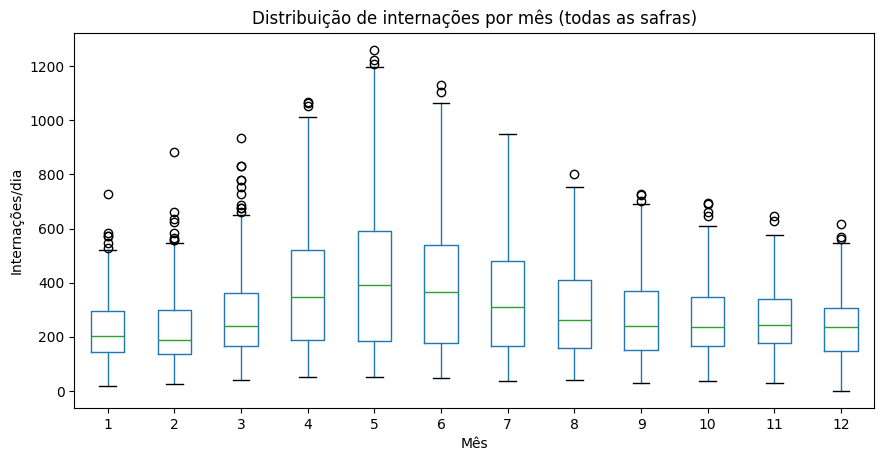

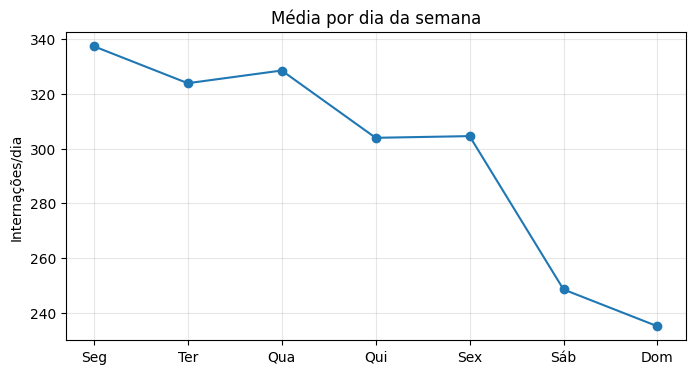

C:\Users\jhter\AppData\Local\Temp\ipykernel_14696\420043506.py:75: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  M = S['y'].resample('M').mean()


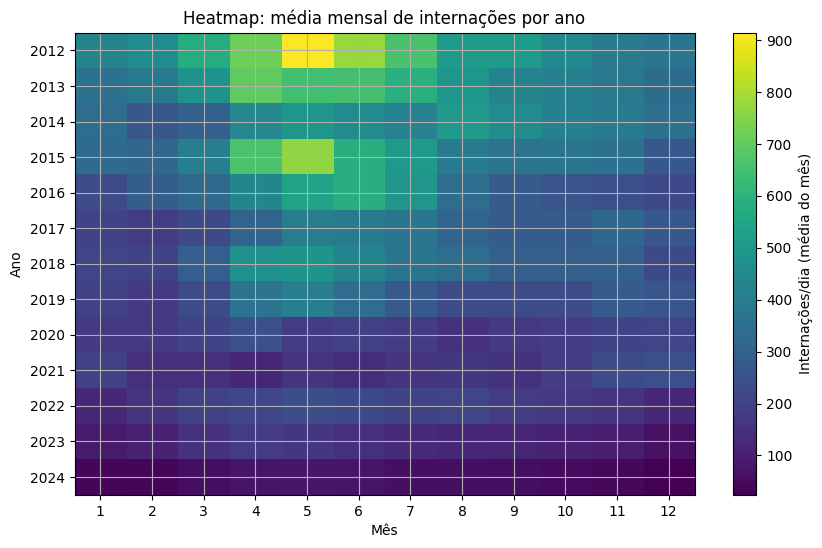

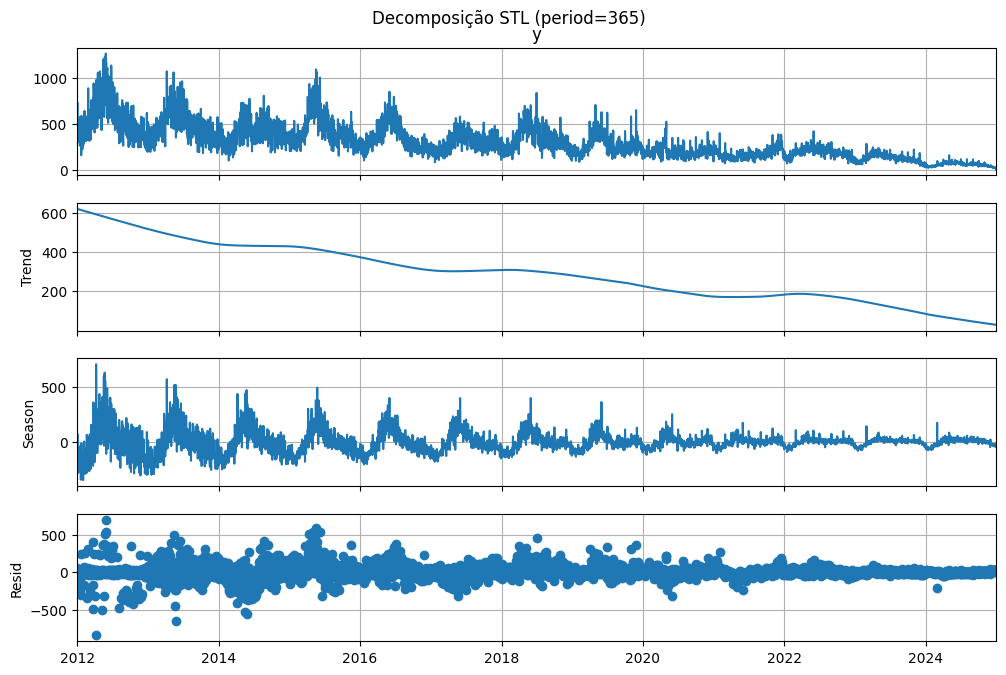

Força da sazonalidade (STL): 0.482
Índice sazonal mensal (treino até 2023-12-31):
month
1     0.760
2     0.751
3     0.926
4     1.273
5     1.414
6     1.292
7     1.145
8     0.995
9     0.910
10    0.883
11    0.880
12    0.773
Name: y, dtype: float64


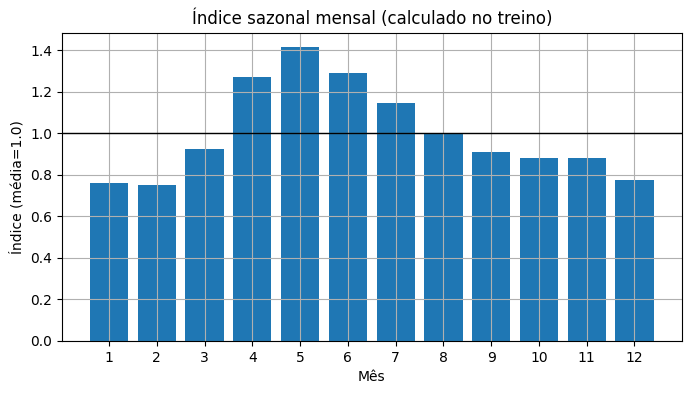

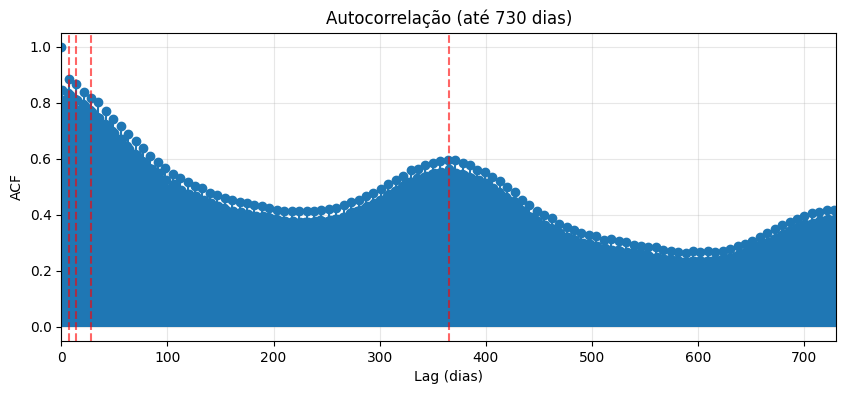

Top períodos (dias) pelo periodograma:
- ~ 365.23 dias (freq=0.00274) potência=3.118e+03
- ~ 182.62 dias (freq=0.00548) potência=1.124e+03
- ~ 395.67 dias (freq=0.00253) potência=8.046e+02
- ~1187.00 dias (freq=0.00084) potência=7.656e+02
- ~   7.00 dias (freq=0.14280) potência=7.508e+02
- ~ 339.14 dias (freq=0.00295) potência=6.361e+02
- ~ 527.56 dias (freq=0.00190) potência=4.725e+02
- ~   6.99 dias (freq=0.14301) potência=2.879e+02
- ~ 279.29 dias (freq=0.00358) potência=2.460e+02
- ~   3.50 dias (freq=0.28580) potência=2.226e+02


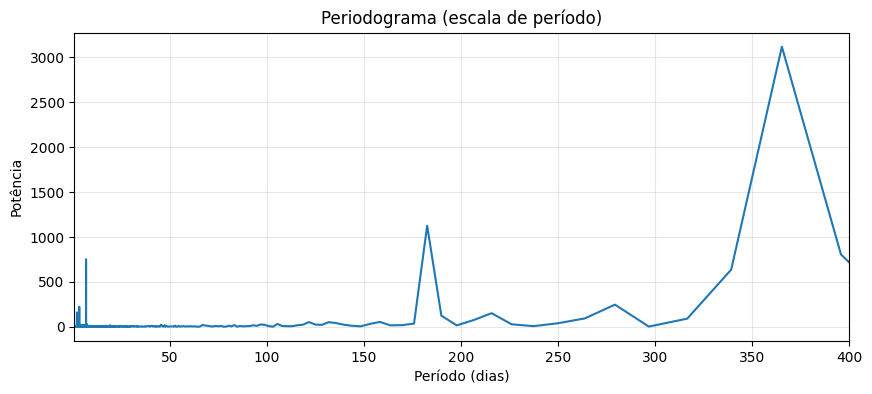

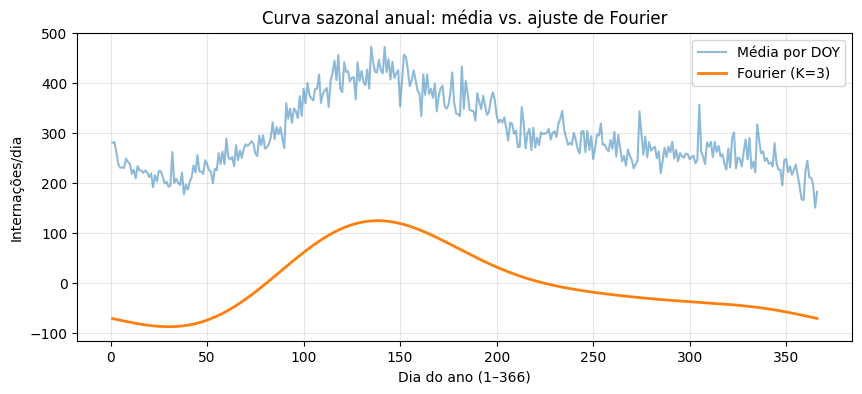

C:\Users\jhter\AppData\Local\Temp\ipykernel_14696\420043506.py:253: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  M = S['y'].resample('M').mean().to_frame('y')


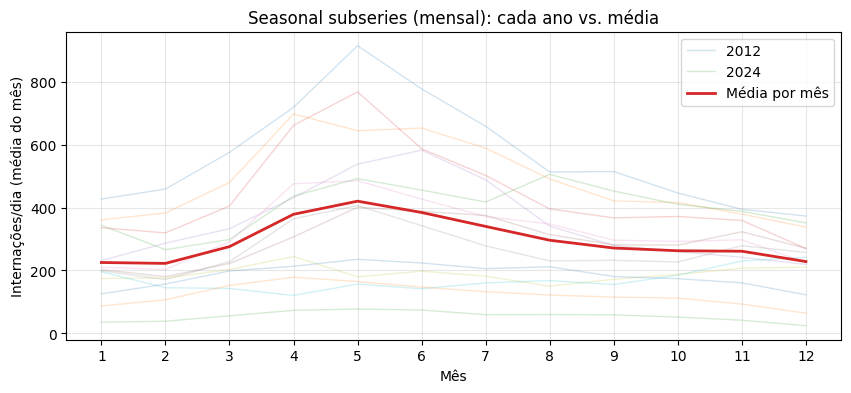

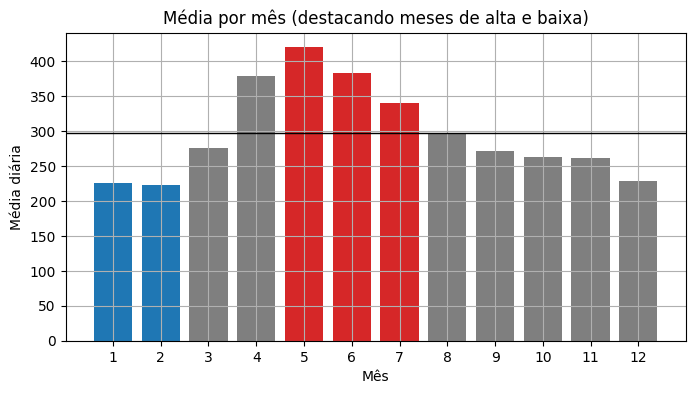

,y,season_m_idx,sin_y1,cos_y1,y_lag_7,y_rollmean_30,flag_alta
date,,,,,,,
2012-01-01,507,0.759554,0.017202,0.999852,NaN,NaN,0
2012-01-02,728,0.759554,0.034398,0.999408,NaN,NaN,0
2012-01-03,429,0.759554,0.051584,0.998669,NaN,NaN,0
2012-01-04,416,0.759554,0.068755,0.997634,NaN,NaN,0
2012-01-05,403,0.759554,0.085906,0.996303,NaN,NaN,0


In [ ]:
def preparar_serie(df, date_col='data_dia', y_col='num_internacoes'):
    """
    Ordena, garante frequência diária, checa faltantes e prepara colunas de calendário.
    Retorna série diária com índice datetime e um DataFrame enriquecido.
    """
    df = df[[date_col, y_col]].copy()
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values(date_col).drop_duplicates(subset=[date_col])

    # Reindexa para frequência diária contínua
    full_idx = pd.date_range(df[date_col].min(), df[date_col].max(), freq='D')
    df = df.set_index(date_col).reindex(full_idx)
    df.index.name = 'date'

    # Interpola valores faltantes de forma conservadora (apenas buracos internos)
    # Em séries de contagem, você pode preferir ffill; aqui uso interp linear por suavidade
    if df[y_col].isna().any():
        df[y_col] = df[y_col].interpolate(method='linear', limit_area='inside')

    # Calendário
    out = df.copy()
    out['year'] = out.index.year
    out['month'] = out.index.month
    out['doy'] = out.index.dayofyear
    out['dow'] = out.index.dayofweek  # 0=Seg ... 6=Dom
    out['week'] = out.index.isocalendar().week.astype(int)
    return out.rename(columns={y_col: 'y'})

S = preparar_serie(internacoes_rj, 'data_dia', 'num_internacoes')

# Plots rápidos de sazonalidade
def plot_boxplot_mes(S):
    """Boxplot por mês (efeito mês-do-ano)."""
    fig, ax = plt.subplots(figsize=(10,5))
    S[['month','y']].assign(month=S['month'].astype(int)).boxplot(by='month', column='y', ax=ax, grid=False)
    ax.set_title('Distribuição de internações por mês (todas as safras)')
    ax.set_xlabel('Mês')
    ax.set_ylabel('Internações/dia')
    plt.suptitle('')
    plt.show()

def plot_media_dow(S):
    """Média por dia-da-semana (efeito semanal)."""
    m = S.groupby('dow')['y'].mean()
    fig, ax = plt.subplots(figsize=(8,4))
    ax.plot(range(7), m.values, marker='o')
    ax.set_xticks(range(7)); ax.set_xticklabels(['Seg','Ter','Qua','Qui','Sex','Sáb','Dom'])
    ax.set_title('Média por dia da semana')
    ax.set_ylabel('Internações/dia')
    ax.grid(True, alpha=0.3)
    plt.show()

def plot_heatmap_ano_mes(S):
    """Heatmap de médias mensais por ano (sazonalidade anual ao longo dos anos)."""
    # Agrega por mês/ano (média diária do mês)
    M = S['y'].resample('M').mean()
    P = M.to_frame().assign(year=M.index.year, month=M.index.month).pivot(index='year', columns='month', values='y')
    fig, ax = plt.subplots(figsize=(10,6))
    im = ax.imshow(P.values, aspect='auto')
    ax.set_yticks(range(len(P.index))); ax.set_yticklabels(P.index)
    ax.set_xticks(range(12)); ax.set_xticklabels(range(1,13))
    ax.set_xlabel('Mês'); ax.set_ylabel('Ano')
    ax.set_title('Heatmap: média mensal de internações por ano')
    cbar = plt.colorbar(im, ax=ax); cbar.set_label('Internações/dia (média do mês)')
    plt.show()

plot_boxplot_mes(S)
plot_media_dow(S)
plot_heatmap_ano_mes(S)

# Decomposição STL (sazonal + tendência)
def stl_decomp(S, period=365):
    """
    Decomposição STL. period=365 para diário; se série for mensal, usar 12.
    Retorna resultado e plota componentes.
    """
    y = S['y']
    # STL exige sem NaN e índice regular (já garantimos)
    stl = STL(y, period=period, robust=True).fit()
    fig = stl.plot()
    fig.set_size_inches(10,7)
    fig.suptitle('Decomposição STL (period={})'.format(period))
    plt.show()

    # Força sazonalidade (Hyndman): 1 - Var(remainder)/Var(seasonal+remainder)
    rem = stl.resid
    seas = stl.seasonal
    seasonal_strength = max(0, 1 - np.var(rem, ddof=1) / np.var(seas + rem, ddof=1))
    print(f"Força da sazonalidade (STL): {seasonal_strength:.3f}")
    return stl

stl_res = stl_decomp(S, period=365)

# Índice sazonal mensal (sem vazamento)
def indice_sazonal_mensal(S, train_end='2023-12-31'):
    """
    Calcula índice sazonal por mês usando apenas o período de treino.
    Normaliza para média 1.0. Anexa coluna 'season_m_idx' ao DataFrame completo.
    """
    train_mask = (S.index <= pd.to_datetime(train_end))
    ref = (S.loc[train_mask]
           .groupby('month')['y'].mean())
    idx = ref / ref.mean()  # média dos 12 meses = 1.0
    S = S.copy()
    S['season_m_idx'] = S['month'].map(idx)
    print('Índice sazonal mensal (treino até {}):'.format(train_end))
    print(idx.round(3))
    return S, idx

S, saz_idx_m = indice_sazonal_mensal(S, train_end='2023-12-31')

# Visualização do índice sazonal
fig, ax = plt.subplots(figsize=(8,4))
ax.bar(saz_idx_m.index, saz_idx_m.values)
ax.set_xticks(range(1,13)); ax.set_xlabel('Mês')
ax.set_ylabel('Índice (média=1.0)')
ax.set_title('Índice sazonal mensal (calculado no treino)')
ax.axhline(1.0, color='k', lw=1)
plt.show()

# Autocorrelação (picos em 7 e ~365 dias)
def plot_acf_custom(S, max_lag=730):
    """
    Plota ACF até 2 anos (~730 dias). Destaque para lags 7 e 365.
    """
    y = S['y'].values
    # normalização opcional para estabilidade
    y = (y - y.mean()) / (y.std() + 1e-9)
    a = acf(y, nlags=max_lag, fft=True)
    fig, ax = plt.subplots(figsize=(10,4))
    ax.stem(range(len(a)), a, basefmt=" ")
    ax.set_xlim(0, max_lag)
    ax.set_xlabel('Lag (dias)')
    ax.set_ylabel('ACF')
    ax.set_title('Autocorrelação (até {} dias)'.format(max_lag))
    for L in [7, 14, 28, 365]:
        ax.axvline(L, color='r', linestyle='--', alpha=0.6)
    ax.grid(True, alpha=0.3)
    plt.show()

plot_acf_custom(S, max_lag=730)

# Periodograma (picos em frequências sazonais)
def periodograma_anual(S):
    """
    Usa periodograma para encontrar frequências dominantes.
    Converte frequências em períodos (dias).
    """
    y = S['y'].values
    y = y - np.mean(y)
    fs = 1.0  # 1 amostra por dia
    f, Pxx = periodogram(y, fs=fs, detrend='linear', scaling='spectrum')
    # evita freq=0
    mask = f > 0
    f, Pxx = f[mask], Pxx[mask]
    # ordena por potência
    tops = np.argsort(Pxx)[::-1][:10]
    print('Top períodos (dias) pelo periodograma:')
    for i in tops:
        period_days = 1.0 / f[i]
        print(f"- ~{period_days:7.2f} dias (freq={f[i]:.5f}) potência={Pxx[i]:.3e}")

    # Plot
    fig, ax = plt.subplots(figsize=(10,4))
    ax.plot(1.0/f, Pxx)
    ax.set_xlim(1, 400)  # foco até ~1 ano
    ax.set_xlabel('Período (dias)')
    ax.set_ylabel('Potência')
    ax.set_title('Periodograma (escala de período)')
    ax.grid(True, alpha=0.3)
    plt.show()

periodograma_anual(S)


# Curva sazonal com Fourier (anual)
def ajustar_fourier_anual(S, K=3):
    """
    Ajusta y ~ beta0 + sum_k [a_k sin(2πk*doy/365.25) + b_k cos(...)]
    Retorna série com componente sazonal estimada e plota.
    """
    n = len(S)
    X = [np.ones(n)]
    for k in range(1, K+1):
        X.append(np.sin(2*np.pi*k*S['doy']/365.25))
        X.append(np.cos(2*np.pi*k*S['doy']/365.25))
    X = np.column_stack(X)
    beta, *_ = lstsq(X, S['y'].values, rcond=None)
    saz = X @ beta - beta[0]  # remove intercepto para realçar apenas sazonalidade

    out = S.copy()
    out['fourier_seasonal'] = saz

    fig, ax = plt.subplots(figsize=(10,4))
    # média por dia-do-ano (suaviza a visualização)
    df_plot = out.groupby('doy')[['y','fourier_seasonal']].mean()
    ax.plot(df_plot.index, df_plot['y'], label='Média por DOY', alpha=0.5)
    ax.plot(df_plot.index, df_plot['fourier_seasonal'], label=f'Fourier (K={K})', lw=2)
    ax.set_xlabel('Dia do ano (1–366)')
    ax.set_ylabel('Internações/dia')
    ax.set_title('Curva sazonal anual: média vs. ajuste de Fourier')
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.show()

    return out

S = ajustar_fourier_anual(S, K=3)

# Sazonalidade mensal da série agregada (subseries)
def seasonal_subseries_mensal(S):
    """
    Agrega a série para mensal (média diária do mês) e plota:
    - média por mês (linha)
    - séries por ano (linhas finas) para ver consistência da sazonalidade
    """
    M = S['y'].resample('M').mean().to_frame('y')
    M['year'] = M.index.year
    M['month'] = M.index.month

    fig, ax = plt.subplots(figsize=(10,4))
    for yr, g in M.groupby('year'):
        ax.plot(g['month'], g['y'], alpha=0.2, lw=1, label=str(yr) if yr in [M['year'].min(), M['year'].max()] else None)
    ax.plot(range(1,13), M.groupby('month')['y'].mean().values, lw=2, label='Média por mês')
    ax.set_xticks(range(1,13)); ax.set_xlabel('Mês')
    ax.set_ylabel('Internações/dia (média do mês)')
    ax.set_title('Seasonal subseries (mensal): cada ano vs. média')
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.show()

seasonal_subseries_mensal(S)

# Flags de estação (ex.: jan–fev baixa; mai–jul alta)
def plot_flags_estacao(S, meses_alta=[5,6,7], meses_baixa=[1,2]):
    """Mostra médias por mês realçando grupos de meses de interesse."""
    mean_m = S.groupby('month')['y'].mean()
    fig, ax = plt.subplots(figsize=(8,4))
    colors = []
    for m in range(1,13):
        if m in meses_alta: colors.append('#d62728') 
        elif m in meses_baixa: colors.append('#1f77b4')  
        else: colors.append('#7f7f7f') 
    ax.bar(range(1,13), mean_m.values, color=colors)
    ax.set_xticks(range(1,13)); ax.set_xlabel('Mês'); ax.set_ylabel('Média diária')
    ax.set_title('Média por mês (destacando meses de alta e baixa)')
    ax.axhline(mean_m.mean(), color='k', lw=1)
    plt.show()

plot_flags_estacao(S, meses_alta=[5,6,7], meses_baixa=[1,2])


def criar_features_sazonais(S, K_fourier=3):
    """
    Cria features prontas para modelagem (sem treinamento ainda):
    - Dummies de mês
    - Fourier anual (K termos)
    - Índice sazonal mensal calculado no treino (já anexado na etapa 3, se você chamou antes)
    - Lags e rollings sazonais comuns
    """
    X = S.copy()

    # Dummies de mês (evita dummy trap retirando a 1ª)
    month_dummies = pd.get_dummies(X['month'].astype(int), prefix='m', drop_first=True)
    X = pd.concat([X, month_dummies], axis=1)

    # Fourier anual
    for k in range(1, K_fourier+1):
        X[f'sin_y{k}'] = np.sin(2*np.pi*k*X['doy']/365.25)
        X[f'cos_y{k}'] = np.cos(2*np.pi*k*X['doy']/365.25)

    # Lags típicos (ajuste à sua realidade)
    for lag in [7, 14, 28, 365]:
        X[f'y_lag_{lag}'] = X['y'].shift(lag)

    # Médias móveis (shiftadas para evitar vazamento no dia t)
    for w in [7, 30, 60]:
        X[f'y_rollmean_{w}'] = X['y'].shift(1).rolling(w).mean()
        X[f'y_rollstd_{w}']  = X['y'].shift(1).rolling(w).std()

    # Flags simples
    X['flag_alta']  = X['month'].isin([5,6,7]).astype(int)
    X['flag_baixa'] = X['month'].isin([1,2]).astype(int)

    return X

X_features = criar_features_sazonais(S)
X_features[['y','season_m_idx','sin_y1','cos_y1','y_lag_7','y_rollmean_30','flag_alta']].head()


## EDA


### Tendência temporal (série diária)

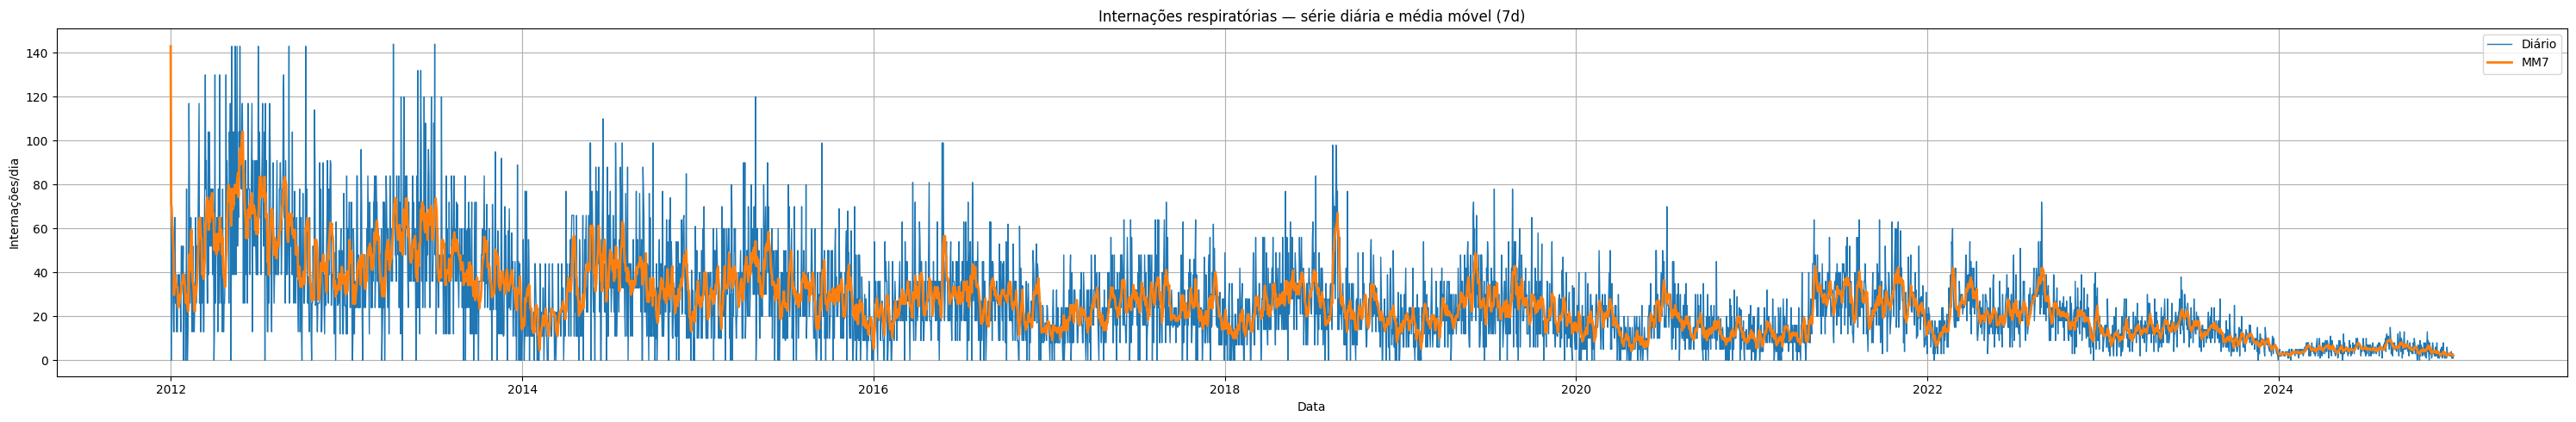

In [13]:

plt.figure(figsize=(30, 5))
plt.plot(internacoes_rj["data_dia"], internacoes_rj["num_internacoes"], linewidth=1, label="Diário")
plt.plot(internacoes_rj["data_dia"], internacoes_rj["internacoes_mm7"], linewidth=2, label="MM7")
plt.title("Internações respiratórias — série diária e média móvel (7d)")
plt.xlabel("Data")
plt.ylabel("Internações/dia")
plt.legend()
plt.tight_layout()
plt.show()


### Sazonalidade (mês e dia da semana)

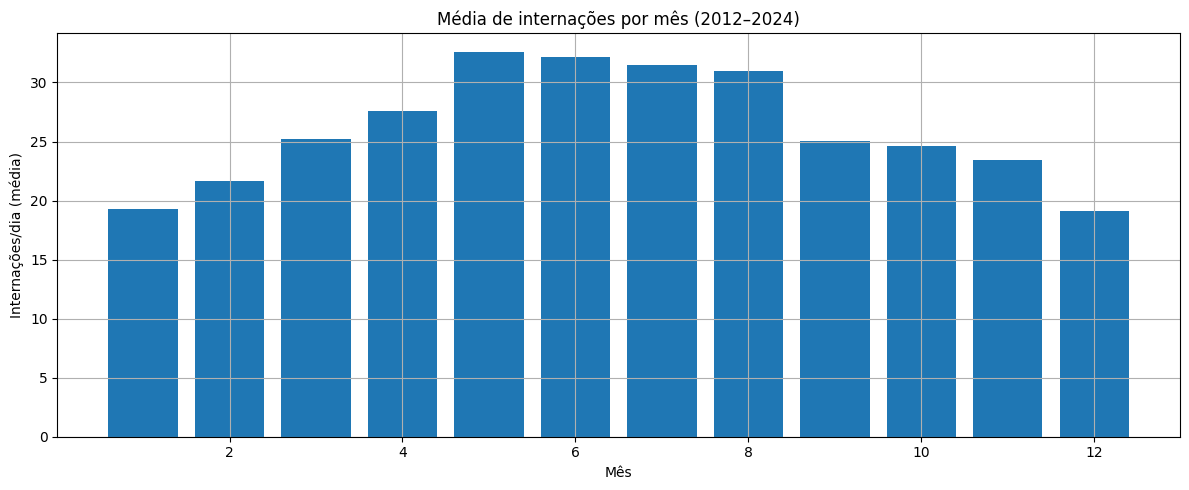

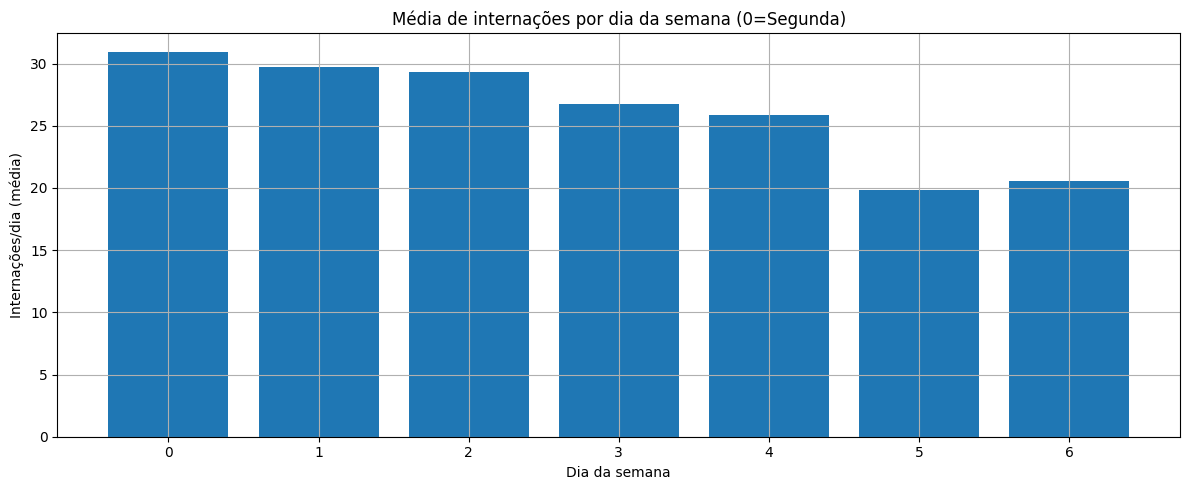

In [14]:
tmp = internacoes_rj.copy()
tmp["mes"] = tmp["data_dia"].dt.month
tmp["dow"] = tmp["data_dia"].dt.day_of_week  # 0=segunda

by_month = tmp.groupby("mes")["num_internacoes"].mean().reindex(range(1,13))
plt.figure()
plt.bar(by_month.index, by_month.values)
plt.title("Média de internações por mês (2012–2024)")
plt.xlabel("Mês")
plt.ylabel("Internações/dia (média)")
plt.tight_layout()
plt.show()

by_dow = tmp.groupby("dow")["num_internacoes"].mean().reindex(range(0,7))
plt.figure()
plt.bar(by_dow.index, by_dow.values)
plt.title("Média de internações por dia da semana (0=Segunda)")
plt.xlabel("Dia da semana")
plt.ylabel("Internações/dia (média)")
plt.tight_layout()
plt.show()



### Distribuições (idade e permanência)


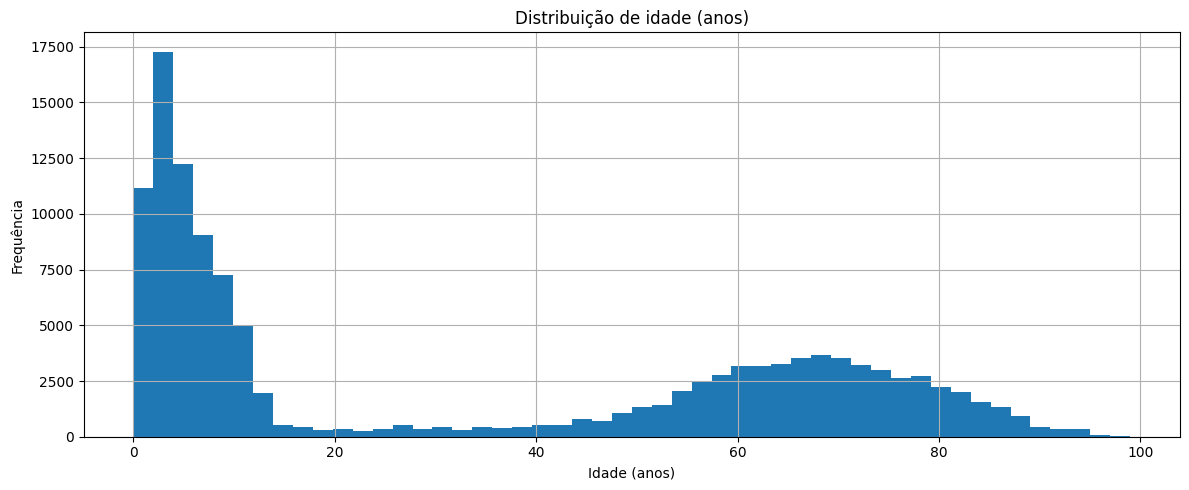

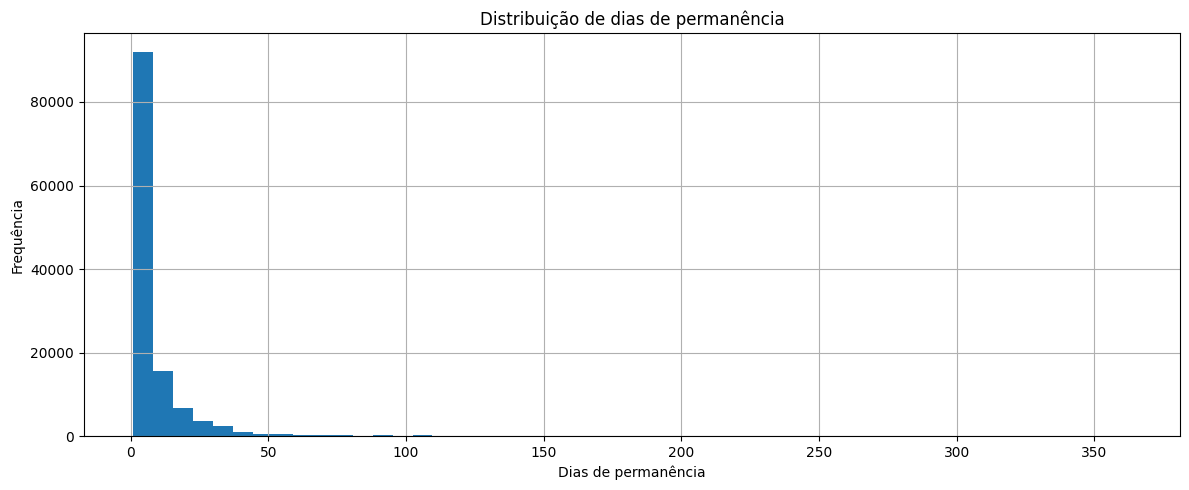

In [15]:

if "IDADE" in sus_filtrado.columns:
    x = pd.to_numeric(sus_filtrado["IDADE"], errors="coerce").dropna()
    plt.figure()
    plt.hist(x.values, bins=50)
    plt.title("Distribuição de idade (anos)")
    plt.xlabel("Idade (anos)")
    plt.ylabel("Frequência")
    plt.tight_layout()
    plt.show()

if "DIAS_PERM" in sus_filtrado.columns:
    los = pd.to_numeric(sus_filtrado["DIAS_PERM"], errors="coerce").dropna()
    plt.figure()
    plt.hist(los.values, bins=50)
    plt.title("Distribuição de dias de permanência")
    plt.xlabel("Dias de permanência")
    plt.ylabel("Frequência")
    plt.tight_layout()
    plt.show()


### Composição por diagnóstico (CID-10)

In [16]:
if "CID_PREFIXO" in sus_filtrado.columns:
    vc = sus_filtrado["CID_PREFIXO"].value_counts().sort_values(ascending=False)
    display(vc.to_frame("contagem").head(10))

,contagem
CID_PREFIXO,
J45,63248
J44,46574
J43,5981
J40,4878
J42,1467
J46,1076
J41,790
